# 0. 가상환경 불러오기
이전에 만들어둔 가상환경 불러오기

## conda prompt

### 콘다 버전 확인
conda --version

### 콘다로 가상환경 생성
conda create -n spatial python=3.10 

### 가상환경 활성화
conda activate spatial

## Select kernel 설정 변경

### 설치 라이브러리
pip install scikit-misc

# 1. RAW DATA 불러와서 데이터 구조 확인하기

In [3]:
# import pandas as pd

# df = pd.read_csv('dataset/GSE127465_RAW/GSM3635280_human_p1t3_raw_counts.tsv.gz', sep='\t', index_col=0, compression='gzip')
# print(df.shape)
# print(df.head())

## 2. RAW DATA 합쳐주기
- 이제 불러온 RAW 데이터 파일 안에 들어있는 모든 tsv파일을 합쳐주어야 한다.

In [4]:
import scanpy as sc
import pandas as pd
import scipy.sparse as sp
import glob
from tqdm import tqdm

files = glob.glob('dataset/raw/GSE127465_RAW/*human*.tsv.gz')

# 데이터 구조 확인 (최초 1회만 실행)
df_check = pd.read_csv(files[0], sep='\t', index_col=0, compression='gzip')
print('shape:', df_check.shape)
print('index(행):', df_check.index[:3].tolist())
print('columns(열):', df_check.columns[:3].tolist())
del df_check
'''
    만약, 행 -> 세포 / 열 -> 유전자 라면 밑에 adata에 대입해줄 때 df.values
        열 -> 세포 / 행 -> 유전자 (반대) 라면 밑에 adata에 대입해줄 때 df.T.values
    내가 쓴 데이터는 전치 안해줘도 됐음
'''

adata_list = []
for f in tqdm(files):
    df = pd.read_csv(f, sep='\t', index_col=0, compression='gzip')
    
    # sparse 변환으로 메모리 절약
    adata = sc.AnnData(sp.csr_matrix(df.values.astype('float32')))
    adata.obs_names = df.index.tolist()
    adata.var_names = df.columns.tolist()
    
    adata_list.append(adata)
    del df # 파일 하나 당 한개씩 할당 받은 df를 바로 해제 해줌

adata_raw = sc.concat(adata_list, join='outer', index_unique='-')
del adata_list
print(adata_raw.shape)

adata_raw.write_h5ad('GSE127465_human_all.h5ad')

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [5]:
# 합쳐진 데이터 확인

print(f'세포: {adata_raw.obs_names[:5]}')
print(f'유전자: {adata_raw.var_names[:5]}')
print(f'세포 x 유전자: {adata_raw.shape}')

NameError: name 'adata_raw' is not defined

## 3. 합친 RAW DATA 확인
- 합쳐진 RAW DATA가 행렬에 맞게 잘 들어갔는지 확인
(위에는 데이터를 합치는 단계였고 여기서부터는 데이터가 준비 된 상태이기에 여기서부터 밑으로 쭉 돌리면 파이프 라인 확인 가능)

In [2]:
import scanpy as sc

adata = sc.read_h5ad('dataset/raw/GSE127465_human_all.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 173954 × 41861


## 4. QC 지표 시각화
- count depth, 세포 당 발현 유전자 수, 미토콘드리아 유전자 비율 등을 시각화하여 어떻게 데이터를 정제하고 처리할 것인지 분석 및 판단

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb']


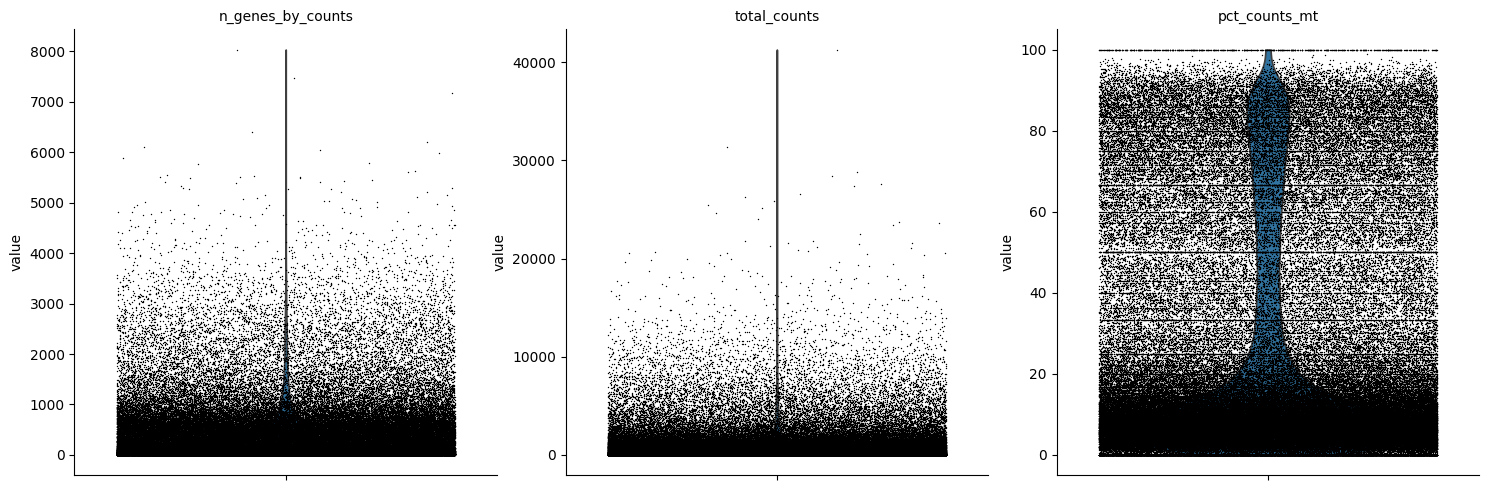

In [4]:
import scanpy as sc

adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
adata.var['hb'] = adata.var_names.str.contains(r'^HB[ABDEGMQZ]\d*(?!\w)')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], percent_top=None, log1p=True, inplace=True)

print(adata.obs.columns.tolist())

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

## 5. MAD Filtering 적용
데이터 분포에서 중앙 값 기준으로 얼마나 벗어났는지를 측정하고 많이 벗어난 값을 필터링 할 수 있다

In [5]:
import numpy as np
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | \
              (np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

adata.obs['outlier'] = (
    is_outlier(adata, 'log1p_total_counts', 5)
    | is_outlier(adata, 'log1p_n_genes_by_counts', 5)
)

adata.obs['mt_outlier'] = is_outlier(adata, 'pct_counts_mt', 3) | (adata.obs['pct_counts_mt'] > 20)

print(adata.obs['outlier'].value_counts())
print(adata.obs['mt_outlier'].value_counts())

outlier
False    173954
Name: count, dtype: int64
mt_outlier
False    115982
True      57972
Name: count, dtype: int64


필터링 전 세포 수: 173954
필터링 후 세포 수: 115982


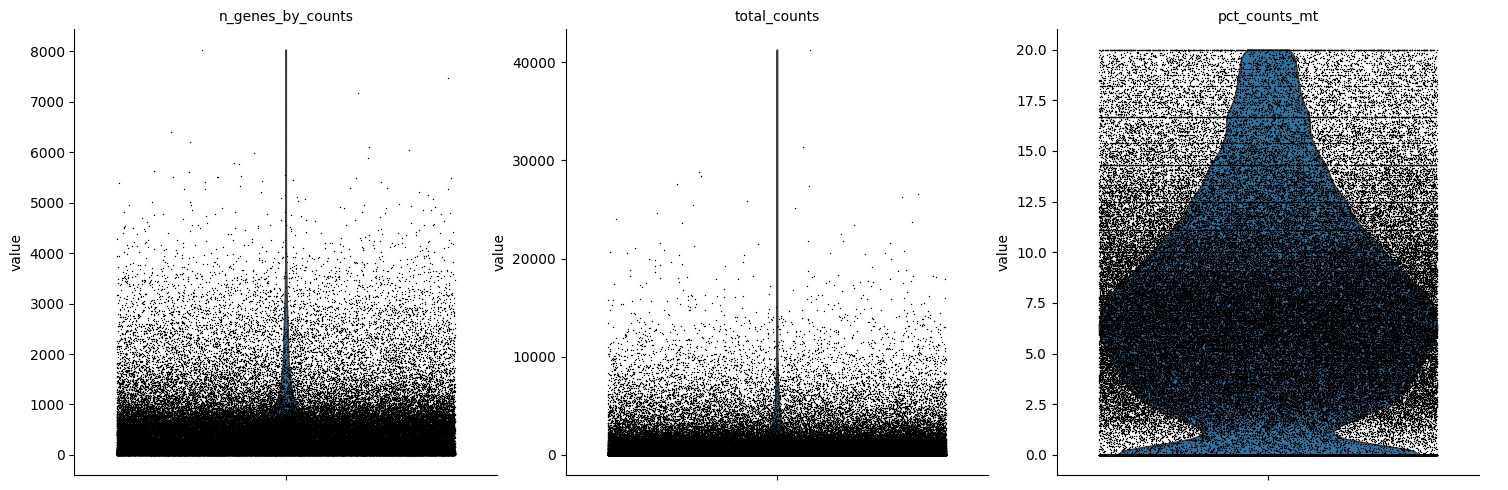

In [6]:
print(f'필터링 전 세포 수: {adata.n_obs}')
adata = adata[(~adata.obs['outlier']) & (~adata.obs['mt_outlier'])].copy()
print(f'필터링 후 세포 수: {adata.n_obs}')

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

## 6. Normalization 적용
: 비교를 위하여 세포 sequencing 깊이 기준치를 하나 잡아서 비교하려는 모든 세포들의 count를 맞춰주는 작업

In [7]:
# normalize_total 실행 시 'Some cells have zero counts' 경고 발생
# QC 후에도 total count = 0인 세포가 남음 -> 0으로 나누기 방지를 위해 먼저 제거

sc.pp.filter_cells(adata, min_counts=1)
print(f'0 count 제거 후: {adata.n_obs}')

# raw count 보존 - 나중에 DEG 분석 시 사용 할 것
adata.layers['counts'] = adata.X.copy()

# normalization 진행
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(adata)

0 count 제거 후: 115909
AnnData object with n_obs × n_vars = 115909 × 41861
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'


## 7. HVG 적용
: HVG(High Value Gene) - 41861개의 유전자 중에서 세포마다 발현량 차이가 큰 유전자만 골라 내는 것

차이가 없는 유전자는 세포 타입 구분에 쓸모가 없으니까 제거하고 분석 효율을 높이는 방법이다

HVG 수: 2000


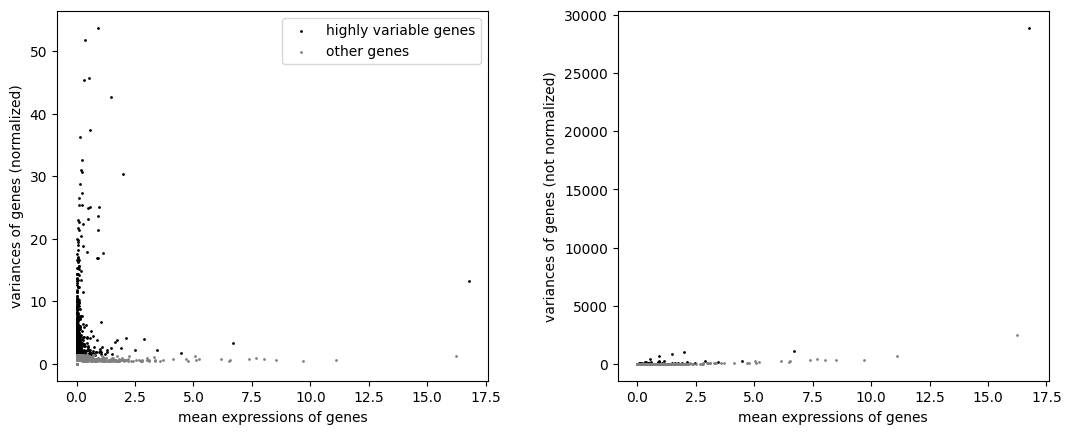

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer='counts')

print(f'HVG 수: {adata.var.highly_variable.sum()}')
sc.pl.highly_variable_genes(adata)

In [ ]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
print(adata.shape)

(115909, 2000)


위에 shape로 출력 된 값을 보면 115909개의 세포와 2000개의 유전자로 HVG를 통해 줄어든 것을 확인 가능

## 8. PCA 적용

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\82108\anaconda3\envs\spatial\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


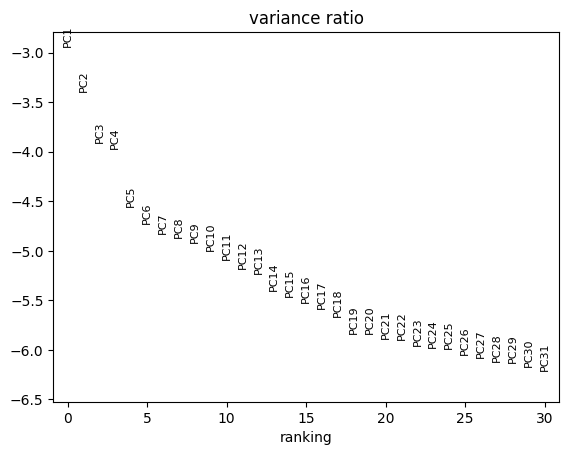

In [11]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)